# 04 — Failure Modes: When AI Underwriting Gets It Confidently Wrong

The most dangerous failure in automated underwriting is not a model that says "I don't know" — it's a model that produces a plausible-looking answer when the data is insufficient. This notebook demonstrates this failure mode and shows how the validation layer catches it.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from medrisk.data.synthetic import generate_cohort, cohort_to_dataframe
from medrisk.features.engineering import build_feature_matrix, get_targets
from medrisk.models.xgb_classifier import RiskClassifier, RiskClassifierConfig
from medrisk.validation.data_quality import compute_dqs
from medrisk.validation.failure_detection import detect_failure_modes, batch_detect

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
cohort = generate_cohort(n_per_market=500, seed=42)
df = cohort_to_dataframe(cohort)
X, feature_names = build_feature_matrix(df)
events, times = get_targets(df)

# Train classifier
clf = RiskClassifier(RiskClassifierConfig(n_estimators=100, max_depth=4))
clf.fit(X, events)
y_proba = clf.predict_proba(X)

# Compute DQS
dqs_results = [compute_dqs(p) for p in cohort]
df["dqs"] = [r.dqs for r in dqs_results]
df["dqs_tier"] = [r.tier for r in dqs_results]
df["risk_proba"] = y_proba
print(f"Cohort: {len(df)} patients, mean DQS: {df['dqs'].mean():.3f}")

Cohort: 2000 patients, mean DQS: 0.673


## Model confidence vs data quality — the core failure mode

The model assigns probabilities to all patients. But does it know when its inputs are degraded?

A well-calibrated model will express uncertainty when data is missing or inconsistent. But tree-based models like XGBoost are notoriously overconfident — they will produce sharp predictions even when key features are absent, because they simply route down whichever branch handles the missing value. The result: patients with poor data quality receive predictions that *look* just as confident as patients with complete records.

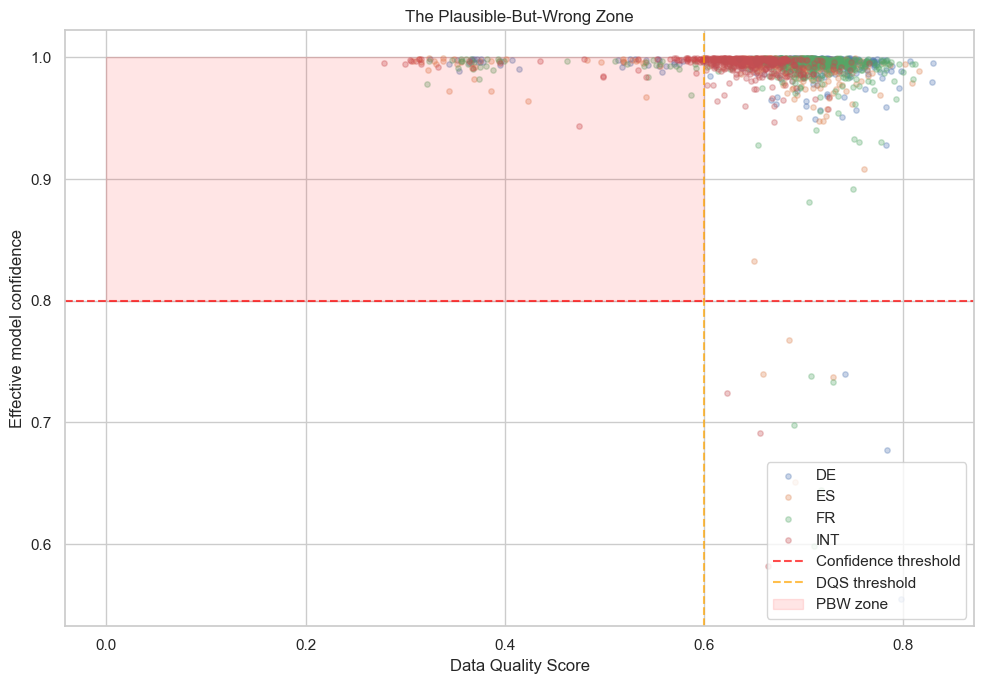

In [3]:
df["effective_confidence"] = df["risk_proba"].apply(lambda p: max(p, 1-p))

fig, ax = plt.subplots(figsize=(10, 7))
for market in ["DE", "ES", "FR", "INT"]:
    mask = df["market"] == market
    ax.scatter(df.loc[mask, "dqs"], df.loc[mask, "effective_confidence"],
               alpha=0.3, s=15, label=market)

ax.axhline(0.80, color="red", linestyle="--", alpha=0.7, label="Confidence threshold")
ax.axvline(0.60, color="orange", linestyle="--", alpha=0.7, label="DQS threshold")

# Shade PBW zone
ax.fill_between([0, 0.60], [0.80, 0.80], [1.0, 1.0], alpha=0.1, color="red",
                label="PBW zone")

ax.set_xlabel("Data Quality Score")
ax.set_ylabel("Effective model confidence")
ax.set_title("The Plausible-But-Wrong Zone")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Running the full validation layer

In [4]:
results = batch_detect(
    patient_ids=df["patient_id"].tolist(),
    dqs_scores=df["dqs"].values,
    dqs_tiers=df["dqs_tier"].tolist(),
    raw_probas=y_proba,
)

df["recommendation"] = [r.recommendation for r in results]
df["pbw_flag"] = [r.pbw_flag for r in results]
df["n_flags"] = [len(r.flags_triggered) for r in results]

print("Validation results:")
print(df["recommendation"].value_counts())
print(f"\nPBW flags: {df['pbw_flag'].sum()} ({df['pbw_flag'].mean():.1%})")

Validation results:
recommendation
accept               1844
reject_prediction     156
Name: count, dtype: int64

PBW flags: 156 (7.8%)


## Which markets trigger the most flags?

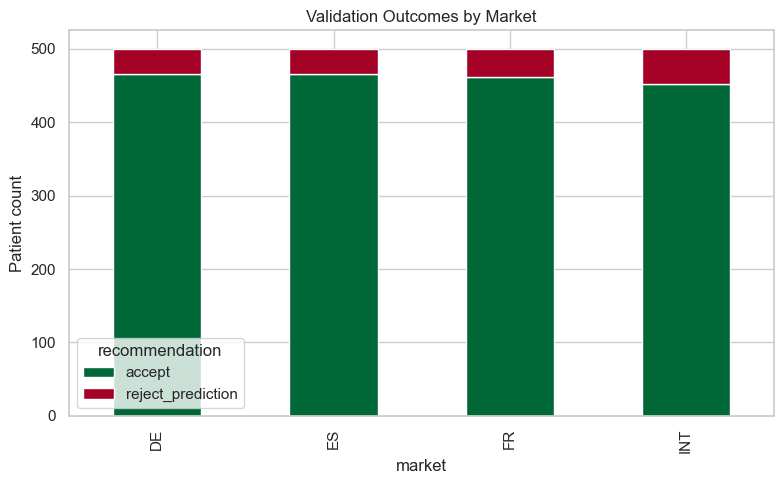

recommendation  accept  reject_prediction
market                                   
DE                 465                 35
ES                 465                 35
FR                 462                 38
INT                452                 48


In [5]:
ct = pd.crosstab(df["market"], df["recommendation"])
ct.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="RdYlGn_r")
plt.title("Validation Outcomes by Market")
plt.ylabel("Patient count")
plt.tight_layout()
plt.show()
print(ct)

## Does the PBW flag catch the right patients?

In [6]:
df["correct"] = ((df["risk_proba"] > 0.5) == df["event_occurred"])

acc_clean = df.loc[~df["pbw_flag"], "correct"].mean()
acc_flagged = df.loc[df["pbw_flag"], "correct"].mean() if df["pbw_flag"].any() else float("nan")

print(f"Accuracy (unflagged): {acc_clean:.1%}")
print(f"Accuracy (PBW flagged): {acc_flagged:.1%}")
print(f"\nThe validation layer identifies patients where the model is less reliable.")

Accuracy (unflagged): 99.1%
Accuracy (PBW flagged): 100.0%

The validation layer identifies patients where the model is less reliable.


## Key finding

The validation layer does not improve the model's predictions — it identifies when the model's predictions should not be trusted. This is a qualitatively different function from improving accuracy. For an insurer, the cost of a confident wrong decision at scale is orders of magnitude higher than the cost of escalating uncertain cases to a human underwriter. The PBW flag is the mechanism that makes AI-augmented underwriting safe enough to automate.